In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.neighbors import KernelDensity
from pyproj import Proj, Transformer, Geod
from pathlib import Path
import argparse
import sys
import os
from scipy import ndimage

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'POSTPROCESSING')))
from ETC_tools import open_files

In [2]:
def prepare_grid(for_coord, sim, transformer):
    """Prépare la grille et gère les noms de variables selon la simulation."""
    if sim == 'ERA5':
        lon_vals = for_coord['longitude'].values
        lat_vals = for_coord['latitude'].values
        grid_lon, grid_lat = np.meshgrid(lon_vals, lat_vals)
    else:
        grid_lat = for_coord['lat'].values
        grid_lon = for_coord['lon'].values
    
    grid_shape = grid_lat.shape
    gx, gy = transformer.transform(grid_lon.ravel(), grid_lat.ravel())
    grid_proj = np.vstack([gx, gy]).T
    return grid_lon, grid_lat, grid_shape, grid_proj

In [3]:
sim = 'ERA5'
season = 'DJF'

In [4]:
tracks, _ = open_files(sim, period_filtering=True)
tracks

Loading data from: /home/vdemeyer/projects/rrg-gachon/vdemeyer/TRACKING/KATJA/OUTPUTS/EETC/EETC_cum_ERA5_Quebec_1000hPa_1979-2023_compound_8hrs_quantile_SSI_diff.pkl with True period filtering


,storm,point,i,j,date,lat,lon,pressure
17090,288,1,1147,223,1980-01-01 19:00:00,34.50,-73.50,1004.430
17091,288,2,1147,223,1980-01-01 20:00:00,34.50,-73.50,1004.190
17092,288,3,1148,222,1980-01-01 21:00:00,34.75,-73.25,1003.810
17093,288,4,1149,222,1980-01-01 22:00:00,34.75,-73.00,1003.570
17094,288,5,1149,222,1980-01-01 23:00:00,34.75,-73.00,1003.300
...,...,...,...,...,...,...,...,...
486181,8063,52,1167,111,2004-12-29 14:00:00,62.50,-68.50,989.521
486182,8063,53,1168,110,2004-12-29 15:00:00,62.75,-68.25,989.763
486183,8063,54,1171,111,2004-12-29 16:00:00,62.50,-67.50,989.963
486184,8063,55,1171,111,2004-12-29 17:00:00,62.50,-67.50,990.003


In [6]:
# Chargement des coordonnées de la grille
coord_path = (
    '/home/vdemeyer/projects/rrg-gachon/vdemeyer/ERA5/PR_Percentile/pr_era5_CORDEX_NA_percentile_1980-2004.nc'
    if sim == 'ERA5' else 
    '/home/vdemeyer/projects/rrg-gachon/vdemeyer/UBB/PR_Percentile/pr_ubb_percentile_1980-2004.nc'
)
for_coord = xr.open_dataset(coord_path)
for_coord

<xarray.Dataset> Size: 8MB
Dimensions:    (latitude: 322, longitude: 732, quantile: 4)
Coordinates:
  * latitude   (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude  (longitude) float32 3kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * quantile   (quantile) float64 32B 0.98 0.99 0.995 0.999
Data variables:
    pr         (quantile, latitude, longitude) float64 8MB ...

In [7]:
# 2. Projection
proj = Proj(proj="laea", lat_0=45, lon_0=-100) # Lambert Azimuthal Equal Area (préserve les aires)
transformer = Transformer.from_proj("epsg:4326", proj, always_xy=True)

# 3. Filtrage des points
lon, lat = tracks["lon"].values, tracks["lat"].values
dates = pd.to_datetime(tracks["date"].values)

if season != 'ALL':
    months_dict = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5], 'JJA': [6, 7, 8], 'SON': [9, 10, 11]}
    s_mask = dates.month.isin(months_dict[season])
    lon, lat, dates = lon[s_mask], lat[s_mask], dates[s_mask]

n_months = dates.to_period("M").nunique()
n_tracks = len(lon)
    
# Transformation des points en coordonnées projetées (mètres)
x, y = transformer.transform(lon, lat)
points_proj = np.vstack([x, y]).T

    # 4. Calcul KDE
grid_lon, grid_lat, grid_shape, grid_proj = prepare_grid(for_coord, sim, transformer)
grid_shape

(322, 732)

In [8]:
bandwidth_km = 200
kde = KernelDensity(bandwidth=bandwidth_km * 1000, kernel="gaussian")
kde.fit(points_proj)
    
# score_samples renvoie log(densité de probabilité). Intégrale de exp(log_dens) = 1
log_dens = kde.score_samples(grid_proj)
dens_prob = np.exp(log_dens).reshape(grid_shape)

# 5. Normalisation Physique
# dens_prob est en [1/m²]. On multiplie par N pour avoir [tracks/m²]
dens_tracks_m2 = dens_prob * n_tracks
    
# Conversion en [tracks / km² / month]
dens_abs = (dens_tracks_m2 * 1e6) / n_months

TypeError: 'tuple' object is not callable

In [9]:
output_dir = Path(f"/project/rrg-gachon/vdemeyer/{sim}/DENSITY")
output_dir.mkdir(parents=True, exist_ok=True)

if sim == 'ERA5':
    coords = {"latitude": for_coord['latitude'].values, "longitude": for_coord['longitude'].values}
    dims = ("latitude", "longitude")
else:
    coords = {
        "rlat": for_coord.rlat, 
        "rlon": for_coord.rlon,
        "lat": (("rlat", "rlon"), grid_lat),
        "lon": (("rlat", "rlon"), grid_lon)
    }
    dims = ("rlat", "rlon")

da = xr.DataArray(
    dens_abs.astype(np.float32),
    dims=dims,
    coords=coords,
    name="density_ETCs",
    attrs={"units": "tracks / km² / month", "description": "KDE Cyclone Density"}
)
    
ds = da.to_dataset()
if sim == 'ERA5':
    mask = xr.open_dataarray('/home/vdemeyer/projects/rrg-gachon/vdemeyer/MASK/mask_CRCM6_grid_for_ERA5.nc')
    ds = ds.where(mask, drop=True)
output_path = output_dir / f"density_ETCs_center_{sim.lower()}_{season}.nc"
ds.to_netcdf(output_path)
print(f"Fichier sauvegardé : {output_path}")
ds

Fichier sauvegardé : /project/rrg-gachon/vdemeyer/ERA5/DENSITY/density_ETCs_center_era5_DJF.nc


<xarray.Dataset> Size: 947kB
Dimensions:       (latitude: 322, longitude: 732)
Coordinates:
  * latitude      (latitude) float32 1kB 84.75 84.5 84.25 84.0 ... 5.0 4.75 4.5
  * longitude     (longitude) float32 3kB -180.0 -179.8 -179.5 ... 179.5 179.8
Data variables:
    density_ETCs  (latitude, longitude) float32 943kB 6.466e-09 ... 0.0

In [10]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
import matplotlib
import numpy as np

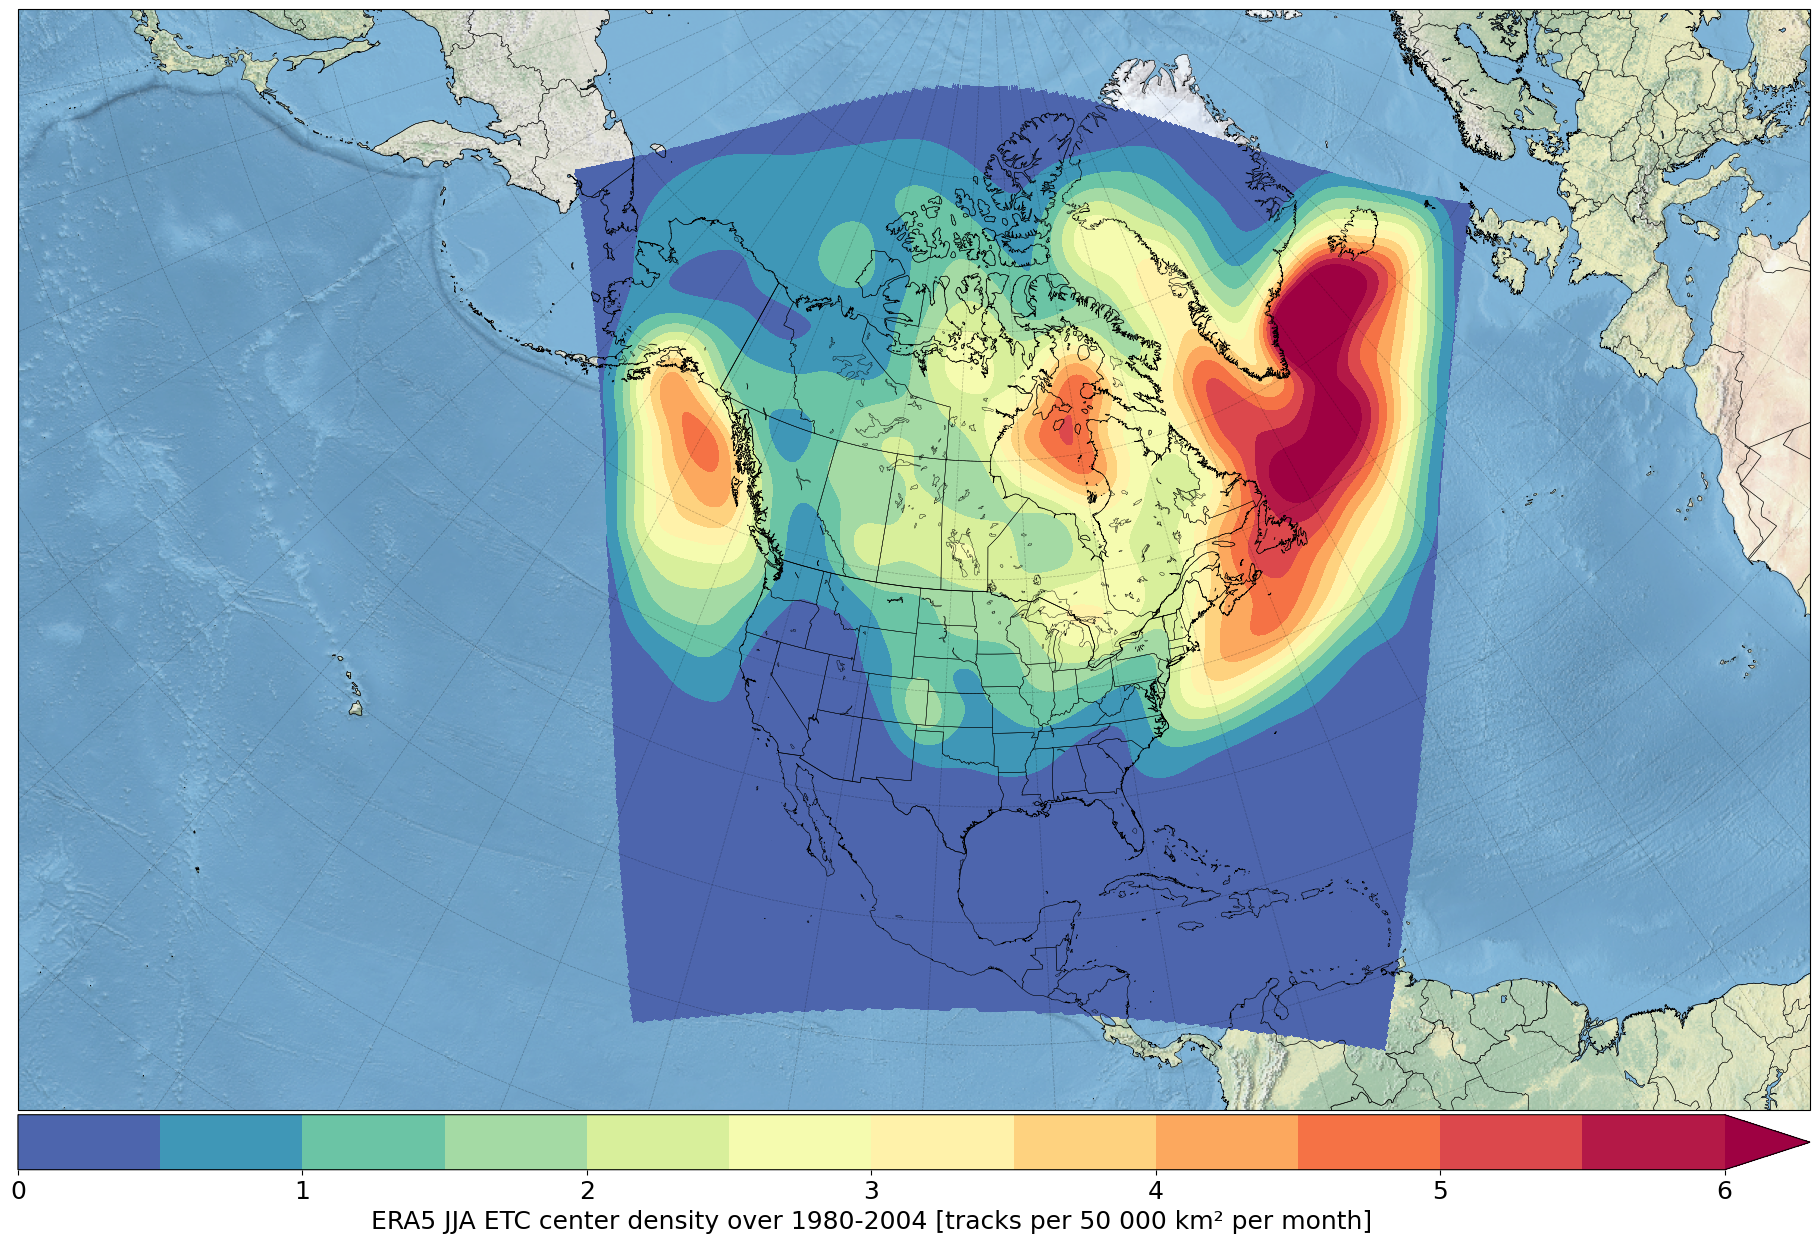

In [19]:
plotcrs = ccrs.LambertConformal(central_latitude=45, central_longitude=-95)

fig, ax = plt.subplots(subplot_kw={'projection': plotcrs},
                       figsize=(18, 16), tight_layout = {'pad': 0})

vmin = 0
vmax = 6.
step = 0.5

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.05, axes_class=plt.Axes)

ax.set_extent([-180, -27, 85, 5], crs=ccrs.PlateCarree())
borders = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_0_boundary_lines_land', scale='50m', facecolor='none')
states_provinces = cartopy.feature.NaturalEarthFeature(category='cultural', name='admin_1_states_provinces', scale='50m', facecolor='none')
lakes_color = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='#7FB4D8', edgecolor='black')
lakes_edge = cartopy.feature.NaturalEarthFeature(category='physical', name='lakes', scale='50m', facecolor='none', edgecolor='black')
img = plt.imread('/home/vdemeyer/TOOLS/NE1_50M_SR_W.tif')
ax.add_feature(borders, linewidth=0.5, edgecolor='black', zorder=2)
ax.add_feature(states_provinces, edgecolor='black', linewidth=0.3)
ax.add_feature(lakes_color, zorder=1, linewidth=0.3)
ax.add_feature(lakes_edge, zorder=2, linewidth=0.3)
ax.coastlines(resolution='10m', linewidth=0.4, color='black')
ax.gridlines(linewidth=0.5, linestyle='--', color='k', alpha=0.25, xlocs=range(-180,180,10), ylocs=range(-90,90,10))
ax.imshow(img, origin='upper', extent=(-180, 180, -90, 90), transform=ccrs.PlateCarree())

sc = ax.contourf(
    ds.longitude, ds.latitude, ds.density_ETCs * 50000.,
    transform=ccrs.PlateCarree(),
    levels=np.arange(vmin, vmax+step, step),
    cmap='Spectral_r',
    extend='max'
)

cbar = fig.colorbar(sc, cax=cax, orientation="horizontal", pad=0.02, aspect=20, extend='max')
cbar.set_label("ERA5 JJA ETC center density over 1980-2004 [tracks per 50 000 km² per month]", fontsize=18)
cbar.ax.tick_params(labelsize=18)